In [5]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv(r"B:\Assignments\Recommendation System\anime.csv")
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [7]:
df.tail()

,anime_id,name,genre,type,episodes,rating,members
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175
12293,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,1,5.46,142


Data Preprossing 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [9]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [10]:
df['episodes']=pd.to_numeric(df['episodes'],errors='coerce')
df['episodes']

0         1.0
1        64.0
2        51.0
3        24.0
4        51.0
         ... 
12289     1.0
12290     1.0
12291     4.0
12292     1.0
12293     1.0
Name: episodes, Length: 12294, dtype: float64

In [11]:
df['genre'].fillna(df['genre'].mode()[0],inplace=True)
df['type'].fillna(df['type'].mode()[0],inplace=True)
df['episodes'].fillna(df['episodes'].mean(),inplace=True)
df['rating'].fillna(df['rating'].mean(),inplace=True)

C:\Users\shyam\AppData\Local\Temp\ipykernel_15408\470246886.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['genre'].fillna(df['genre'].mode()[0],inplace=True)
C:\Users\shyam\AppData\Local\Temp\ipykernel_15408\470246886.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12294 non-null  object 
 3   type      12294 non-null  object 
 4   episodes  12294 non-null  float64
 5   rating    12294 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 672.5+ KB


<Axes: xlabel='type', ylabel='count'>

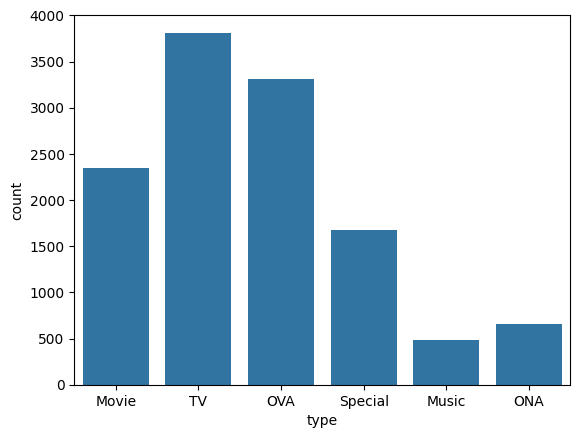

In [13]:
sns.countplot(x='type',data=df)

<Axes: xlabel='rating', ylabel='episodes'>

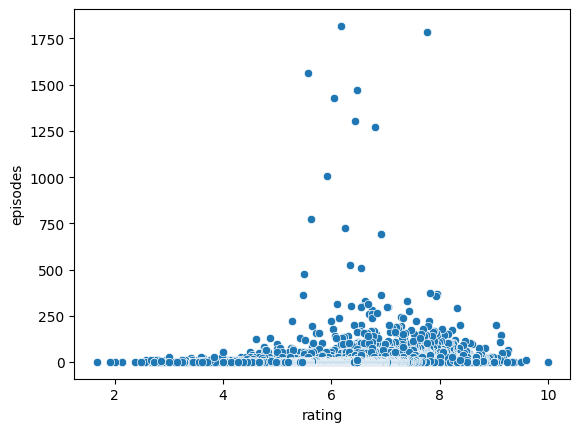

In [14]:
sns.scatterplot(x='rating',y='episodes',data=df)

<Axes: ylabel='Frequency'>

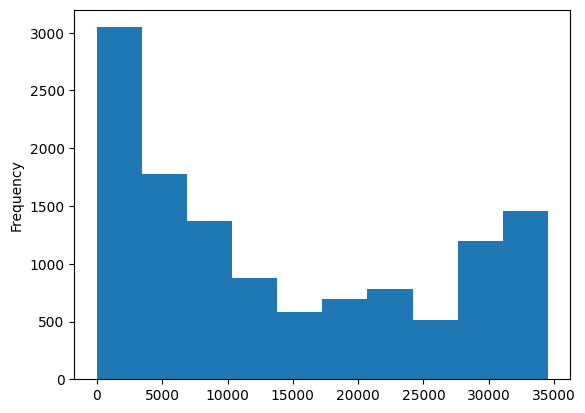

In [15]:
df['anime_id'].plot(kind='hist')

TFIDF vectors from genre column

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english')
tf=tfidf.fit_transform(df['genre'])
tf.toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.29464923, 0.31760665, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.25063144, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [17]:
pd.DataFrame(tf.toarray(),columns=tfidf.get_feature_names_out())

,action,adventure,ai,arts,cars,comedy,dementia,demons,drama,ecchi,...,shounen,slice,space,sports,super,supernatural,thriller,vampire,yaoi,yuri
0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.440247,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.544416,0.000000,0.0,0.0,0.0
1,0.294649,0.317607,0.0,0.0,0.0,0.000000,0.0,0.0,0.335834,0.0,...,0.350987,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
2,0.250631,0.000000,0.0,0.0,0.0,0.200766,0.0,0.0,0.000000,0.0,...,0.298553,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
3,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.833769,0.0,0.0,0.0
4,0.250631,0.000000,0.0,0.0,0.0,0.200766,0.0,0.0,0.000000,0.0,...,0.298553,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12289,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
12290,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
12291,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
12292,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0


In [18]:
tf.shape

(12294, 46)

Knowing similarity's for the movies

In [19]:
from sklearn.metrics.pairwise import cosine_similarity
similarity=cosine_similarity(tf,tf)
similarity

array([[1.        , 0.14784981, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.14784981, 1.        , 0.1786367 , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.1786367 , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        1.        ],
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        1.        ],
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        1.        ]])

In [20]:
movie='Kimi no Na wa.'

In [21]:

idx=df.loc[df['name']==movie].index[0]
idx

np.int64(0)

In [22]:
scores=list(enumerate(similarity[idx]))
scores

[(0, np.float64(1.0)),
 (1, np.float64(0.14784981007855474)),
 (2, np.float64(0.0)),
 (3, np.float64(0.0)),
 (4, np.float64(0.0)),
 (5, np.float64(0.4249925473523769)),
 (6, np.float64(0.0)),
 (7, np.float64(0.15652491384207465)),
 (8, np.float64(0.0)),
 (9, np.float64(0.0)),
 (10, np.float64(0.60788061615937)),
 (11, np.float64(0.5637748610865942)),
 (12, np.float64(0.0)),
 (13, np.float64(0.1250758715631539)),
 (14, np.float64(0.4249925473523769)),
 (15, np.float64(0.6017832880256184)),
 (16, np.float64(0.6307223006790011)),
 (17, np.float64(0.19227389166259454)),
 (18, np.float64(0.0)),
 (19, np.float64(0.17112656185529276)),
 (20, np.float64(0.20226447684520188)),
 (21, np.float64(0.2598324256709115)),
 (22, np.float64(0.1590966999156851)),
 (23, np.float64(0.1799871261513333)),
 (24, np.float64(0.0)),
 (25, np.float64(0.6150352056494524)),
 (26, np.float64(0.39045531854791315)),
 (27, np.float64(0.19227389166259454)),
 (28, np.float64(0.19227389166259454)),
 (29, np.float64(0.0)),

In [23]:
score=sorted(scores,key=lambda x:x [1],reverse=True)
score

[(0, np.float64(1.0)),
 (5805, np.float64(1.0)),
 (6394, np.float64(1.0)),
 (1111, np.float64(0.955317002606888)),
 (1201, np.float64(0.8715047911208604)),
 (1494, np.float64(0.8715047911208604)),
 (878, np.float64(0.8688302781874043)),
 (986, np.float64(0.8688302781874043)),
 (1604, np.float64(0.8688302781874043)),
 (1959, np.float64(0.8548016834935548)),
 (4514, np.float64(0.8548016834935548)),
 (5031, np.float64(0.8548016834935548)),
 (5127, np.float64(0.8548016834935548)),
 (4219, np.float64(0.8488877702367621)),
 (11061, np.float64(0.8488877702367621)),
 (208, np.float64(0.8388152571159246)),
 (504, np.float64(0.8388152571159246)),
 (1435, np.float64(0.8388152571159246)),
 (1436, np.float64(0.8388152571159246)),
 (1631, np.float64(0.8388152571159246)),
 (1907, np.float64(0.8388152571159246)),
 (2300, np.float64(0.8388152571159246)),
 (3297, np.float64(0.8388152571159246)),
 (3530, np.float64(0.8388152571159246)),
 (3908, np.float64(0.8388152571159246)),
 (3914, np.float64(0.838815

In [24]:
movie_index=[tpl[0] for tpl in scores[1:4]]
movie_index

[1, 2, 3]

In [25]:
list(df['name'].iloc[movie_index])


['Fullmetal Alchemist: Brotherhood', 'Gintama°', 'Steins;Gate']

In [26]:
def same_movies(movie, nr_movies):
    
    idx = df[df['name'] == movie].index[0]
    similarity_scores = similarity[idx]
    similar_movie_indices = similarity_scores.argsort()[::-1][1:nr_movies+1]
    recommended_movies = df['name'].iloc[similar_movie_indices].tolist()
    return recommended_movies


In [27]:
same_movies('Under World',4)


['Kamigami no Ki',
 'Yasuji no Pornorama: Yacchimae!!',
 'Violence Gekiga Shin David no Hoshi: Inma Densetsu',
 'Violence Gekiga David no Hoshi']

1)    Can you explain the difference between user-based and item-based collaborative filtering?


ANS:- The user based is worked based on the rating and interacted so, many times the movies is recommend.

      ex:- the user will recommend to another user.

      Where coming to the item based the user the recmmendation will works based user past data.

      ex:- if user seen a 'horrior movie' then he will gets the same kind of movies.
       


2.. What is collaborative filtering, and how does it work?

ANS:- To predict the preferences of a user by collecting preferences or ratings from many users. Collaborative filtering works by leveraging the behavior and interactions of users with items.
